<a href="https://colab.research.google.com/github/harunsy/LogisticRegression.ipynb/blob/main/Hierarchical%20Clustering/Hierarchical_clustering_mall_customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial: Hierarchical Clustering dengan Mall Customer Dataset

Di tutorial ini kita akan belajar mengelompokkan pelanggan sebuah mall berdasarkan **pendapatan tahunan** dan **skor belanja** mereka, menggunakan teknik **Hierarchical Clustering**.

**Apa itu Hierarchical Clustering (singkat)?**
Algoritma yang mengelompokkan data secara bertahap. Pada pendekatan *agglomerative* (bottom-up), setiap data awalnya dianggap satu cluster sendiri, lalu cluster yang paling mirip digabung sedikit demi sedikit sampai terbentuk hierarki. Hierarki ini bisa kita lihat lewat diagram bernama **dendrogram**.

**Library:**
- Python 3 dengan `pandas`, `numpy`, `matplotlib`, `scikit-learn`, dan `scipy`.


**Alur tutorial:**
1. Import library dan load data
2. Memahami isi data
3. Memilih fitur untuk clustering
4. Membuat dendrogram untuk menentukan jumlah cluster
5. Menjalankan `AgglomerativeClustering`
6. Memvisualisasikan hasil cluster
7. Membaca arti setiap cluster
8. Latihan


## Langkah 1: Import library dan load data

Kita mulai dengan mengimpor semua library yang dipakai, lalu membaca dataset langsung dari URL menggunakan `pandas`. Setelah data dimuat, kita cek ukurannya (jumlah baris dan kolom) dan lima baris pertama untuk memastikan data terbaca dengan benar.


In [ ]:
# 1. Import library dan load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

url = 'https://gist.github.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv'
data = pd.read_csv(url)
print('Dataset shape:', data.shape)
print(data.head())

Dataset shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## Langkah 2: Memahami isi data

Dataset ini berisi data pelanggan sebuah mall. Kolom yang penting untuk kita:

- `CustomerID`: nomor identitas pelanggan
- `Gender`: jenis kelamin
- `Age`: usia
- `Annual Income (k$)`: pendapatan tahunan dalam ribuan dollar
- `Spending Score (1-100)`: skor belanja yang diberikan mall (semakin tinggi, semakin sering/banyak belanja)

Kita lihat nama kolom, tipe data, dan ringkasan statistiknya.


In [ ]:
# Info struktur data
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [ ]:
# Ringkasan statistik kolom numerik
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Langkah 3: Memilih fitur untuk clustering

Untuk tutorial ini kita hanya memakai dua fitur, supaya hasilnya mudah divisualisasikan dalam grafik 2 dimensi:

- `Annual Income (k$)`
- `Spending Score (1-100)`

Kita ambil kedua kolom itu, ubah jadi array NumPy, lalu tampilkan sebaran datanya dengan *scatter plot* agar terlihat pola awalnya.


In [ ]:
# Ambil dua fitur utama
X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values
print('Bentuk data fitur:', X.shape)
print(X[:5])

Bentuk data fitur: (200, 2)
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


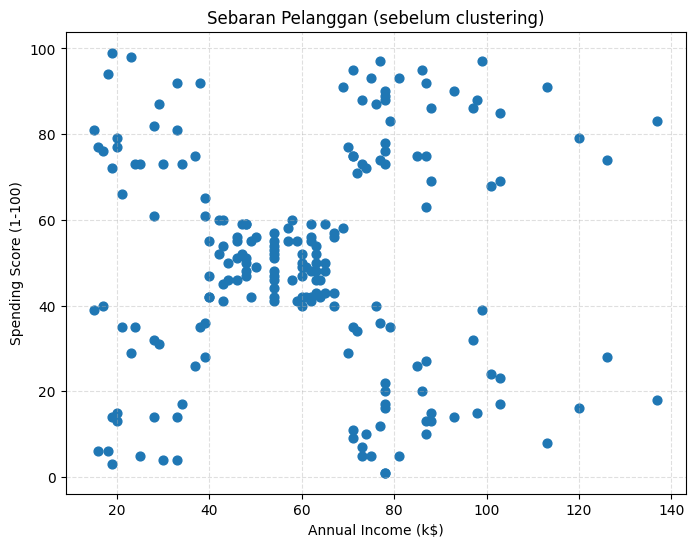

In [ ]:
# Lihat sebaran data sebelum clustering
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=40)
plt.title('Sebaran Pelanggan (sebelum clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Perhatikan grafik di atas: titik-titik tampak mengelompok di beberapa area. Tugas kita adalah membiarkan algoritma menemukan kelompok-kelompok itu secara otomatis.


## Langkah 4: Membuat dendrogram untuk menentukan jumlah cluster

Salah satu kelebihan hierarchical clustering: kita tidak harus menebak jumlah cluster di awal. Kita bisa membuat **dendrogram** dulu, lalu menentukan jumlah cluster dari bentuknya.

Cara membaca dendrogram:
- Sumbu mendatar = data (atau gabungan kelompok data).
- Sumbu tegak = jarak saat dua kelompok digabung. Semakin tinggi garis penggabungan, semakin "jauh" / berbeda kedua kelompok itu.
- Untuk memilih jumlah cluster, cari **garis vertikal terpanjang** yang tidak terpotong garis horizontal, lalu tarik garis potong mendatar di situ. Banyaknya garis vertikal yang dipotong = jumlah cluster.

Kita pakai `linkage` dengan metode `ward` (metode yang umum dipakai karena cenderung menghasilkan cluster berukuran seimbang).


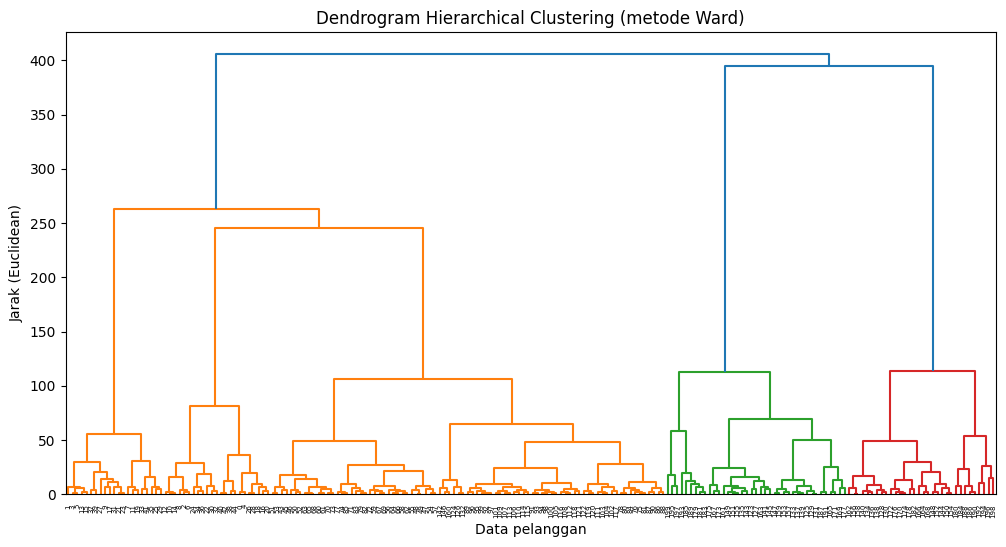

In [ ]:
# Hitung linkage dengan metode Ward
linked = linkage(X, method='ward')

# Gambar dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title('Dendrogram Hierarchical Clustering (metode Ward)')
plt.xlabel('Data pelanggan')
plt.ylabel('Jarak (Euclidean)')
plt.show()


Dendrogram penuh di atas padat karena ada 200 pelanggan. Supaya lebih mudah dibaca, kita tampilkan versi ringkas (`truncate_mode='lastp'`) yang hanya menunjukkan penggabungan-penggabungan terakhir, dan kita tambahkan **garis potong** untuk memperkirakan jumlah cluster.


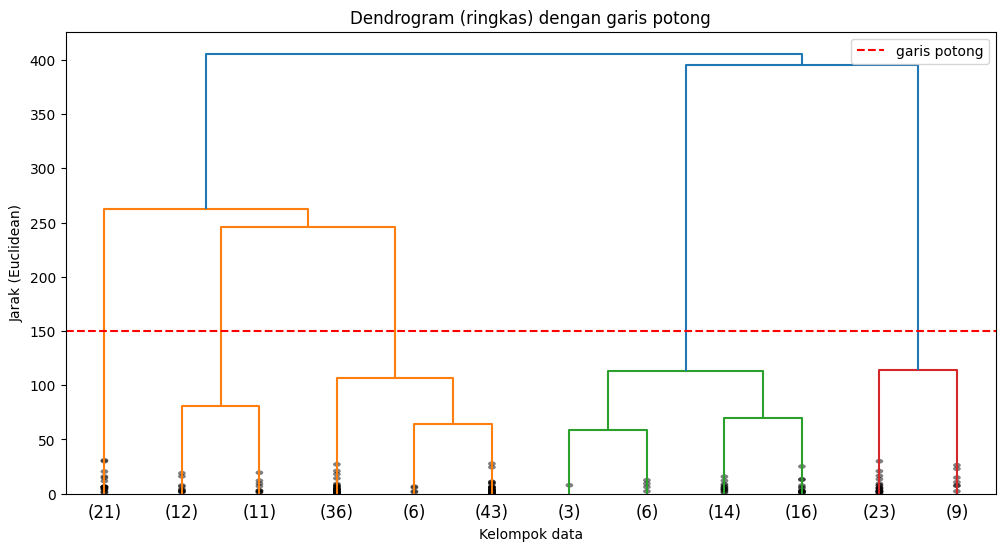

In [ ]:
# Dendrogram versi ringkas + garis potong
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=12, show_contracted=True)
plt.axhline(y=150, color='red', linestyle='--', label='garis potong')
plt.title('Dendrogram (ringkas) dengan garis potong')
plt.xlabel('Kelompok data')
plt.ylabel('Jarak (Euclidean)')
plt.legend()
plt.show()

Garis potong merah memotong beberapa garis vertikal. Dari sini kita memperkirakan jumlah cluster yang masuk akal adalah **5**. Kita boleh menggeser tinggi garis potong (`y=...`) untuk melihat bagaimana jumlah cluster berubah.


## Langkah 5: Menjalankan AgglomerativeClustering

Sekarang kita jalankan algoritmanya dengan jumlah cluster `n_clusters=5` (sesuai pembacaan dendrogram). Kita pakai `linkage='ward'` agar konsisten dengan dendrogram tadi.

Method `fit_predict` akan mengembalikan **label cluster** (0, 1, 2, 3, 4) untuk setiap pelanggan.


In [ ]:
# Jalankan Agglomerative Clustering dengan 5 cluster
model = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = model.fit_predict(X)

# Lihat label untuk 20 pelanggan pertama
print('Label cluster (20 data pertama):')
print(labels[:20])

# Hitung berapa pelanggan di tiap cluster
unique, counts = np.unique(labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'Cluster {c}: {n} pelanggan')

Label cluster (20 data pertama):
[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3]
Cluster 0: 32 pelanggan
Cluster 1: 85 pelanggan
Cluster 2: 39 pelanggan
Cluster 3: 21 pelanggan
Cluster 4: 23 pelanggan


## Langkah 6: Memvisualisasikan hasil cluster

Cara terbaik memahami hasil clustering adalah dengan melihatnya. Kita gambar ulang scatter plot, tetapi sekarang setiap pelanggan diwarnai sesuai label cluster-nya.


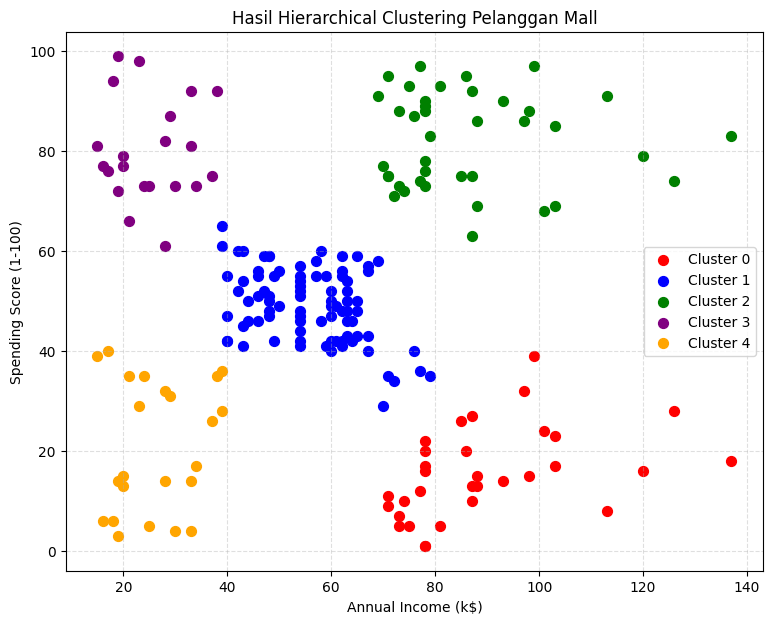

In [ ]:
# Visualisasi hasil clustering
plt.figure(figsize=(9, 7))
colors = ['red', 'blue', 'green', 'purple', 'orange']

for c in range(5):
    plt.scatter(X[labels == c, 0], X[labels == c, 1],
                s=50, color=colors[c], label=f'Cluster {c}')

plt.title('Hasil Hierarchical Clustering Pelanggan Mall')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Setiap warna mewakili satu kelompok pelanggan. Algoritma berhasil memisahkan data menjadi beberapa kelompok yang posisinya berbeda di grafik.


## Langkah 7: Membaca arti setiap cluster

Label angka (0-4) belum berarti apa-apa sampai kita menafsirkannya. Kita tambahkan kolom label ke data, lalu hitung rata-rata income dan spending score per cluster untuk memahami karakter tiap kelompok.


In [ ]:
# Tambahkan label cluster ke DataFrame
data['Cluster'] = labels

# Rata-rata tiap cluster
ringkasan = data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
ringkasan['Jumlah'] = data.groupby('Cluster').size()
ringkasan

,Annual Income (k$),Spending Score (1-100),Jumlah
Cluster,,,
0,89.4,15.6,32
1,55.8,49.1,85
2,86.5,82.1,39
3,25.1,80.0,21
4,26.3,20.9,23


Dari tabel ini kita dapat memberi nama tiap cluster sesuai karakternya, misalnya:

- Pendapatan tinggi + skor belanja tinggi → pelanggan ideal (target promosi premium).
- Pendapatan tinggi + skor belanja rendah → pelanggan hemat (perlu pendekatan khusus).
- Pendapatan rendah + skor belanja tinggi → suka belanja meski pendapatan terbatas.
- Pendapatan rendah + skor belanja rendah → jarang belanja.
- Pendapatan dan skor belanja sedang → pelanggan rata-rata.

Catatan: nomor cluster yang muncul di komputermu bisa berbeda urutannya, jadi tafsirkan berdasarkan angka rata-ratanya, bukan nomornya.


## Latihan

Kerjakan latihan berikut di sel kode kosong yang tersedia. Semua latihan bisa diselesaikan dengan teknik yang sudah dipakai di atas.

**Latihan 1: Ubah jumlah cluster.**
Jalankan ulang `AgglomerativeClustering` dengan `n_clusters=3`, lalu visualisasikan hasilnya. Menurutmu, 3 atau 5 cluster yang lebih cocok untuk data ini? Tulis alasanmu dalam komentar.


In [ ]:
# Tulis kode anda di sini


**Latihan 2: Coba metode linkage lain.**
Buat dendrogram baru menggunakan `method='complete'` (ganti dari `'ward'`) pada fungsi `linkage`. Bandingkan bentuknya dengan dendrogram Ward sebelumnya. Apakah perkiraan jumlah cluster-nya berubah?


In [ ]:
# Tulis kode anda di sini


**Latihan 3: Tambah fitur Age.**
Gunakan tiga fitur sekaligus: `Age`, `Annual Income (k$)`, dan `Spending Score (1-100)`. Jalankan clustering dengan 5 cluster, lalu tampilkan rata-rata ketiga fitur per cluster dengan `groupby`. (Visualisasi 3 fitur tidak wajib, cukup tabel rata-ratanya.)


In [ ]:
# Tulis kode anda di sini


**Latihan 4 (tantangan): Bandingkan dengan jenis kelamin.**
Setelah punya kolom `Cluster`, hitung jumlah pelanggan laki-laki dan perempuan di tiap cluster menggunakan `pd.crosstab(data['Cluster'], data['Gender'])`. Apakah ada cluster yang didominasi satu jenis kelamin?


In [ ]:
# Tulis kode anda di sini


## Ringkasan

Yang sudah kamu pelajari di tutorial ini:

1. **Memuat data** dari URL dengan `pandas` dan mengenali isinya.
2. **Memilih fitur** `Annual Income (k$)` dan `Spending Score (1-100)` untuk clustering.
3. **Membaca dendrogram** untuk memperkirakan jumlah cluster tanpa menebak di awal.
4. **Menjalankan `AgglomerativeClustering`** dari scikit-learn dengan `linkage='ward'`.
5. **Memvisualisasikan** hasil cluster dan **menafsirkan** karakter tiap kelompok pelanggan.

Konsep penting yang perlu diingat:
- Hierarchical clustering membangun hierarki kelompok secara bertahap; dendrogram adalah peta hierarki itu.
- Jumlah cluster ditentukan dari tinggi garis potong pada dendrogram, bukan ditebak begitu saja.
- Hasil clustering baru bermanfaat setelah ditafsirkan, misalnya untuk strategi pemasaran berbasis segmen pelanggan.

Lanjutan yang bisa kamu coba sendiri: melakukan *scaling* fitur sebelum clustering, mencoba metode linkage lain (`average`, `single`), atau membandingkan hasilnya dengan algoritma K-Means.
